# SI Figure S2: Stability & Reproducibility Tests

Layout: 2 rows × 2 columns
- Panel a: MACE Force Field Sensitivity (scatter) with ΔE histogram inset (from old SI-1 c+d merged)
- Panel b: Cross-Backend Slip Agreement heatmap (from old SI-2 panel a)
- Panel c: Site Transition Matrix (from old SI-2 panel b)
- Panel d: Multi-Seed Reproducibility boxplot (from old SI-2 panel c)

Note: GPT and Claude slip data are placeholders — to be updated.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.style.use('default')
sns.set_theme(style='ticks', context='paper', font_scale=1.2)
okabe = ['#5DA0CB', "#141F48", '#F37122', '#FDECAF']
colors = ['#7EA6E0', '#F08A7B', '#FFCC00', '#43B988']
panel_a_map = {
    'gemini': ('gemini', 'Gemini 2.5 Pro', '#7EA6E0'),
    'openai_gpt54': ('gpt', 'GPT-5.4', '#F08A7B'),
    'anthropic_sonnet46': ('claude', 'Claude Sonnet 4.6', '#FFCC00'),
    'grok4': ('grok4', 'Grok-4', '#43B988'),
}
BASE = Path('../../..')
print('Libraries loaded')


Libraries loaded


In [5]:
# === Load Panel a (MACE sensitivity, from old SI-1 panel c) ===
df_s = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/gpt/full/summary.csv')
sm = df_s.set_index('case_id')['best_energy'].to_dict()
df_l = pd.read_csv(BASE / 'research/results/processed/si_figures/advanced_experiments/mace_force_field_sensitivity/cmu20_gpt_full_mace_mp0_large/ablation_summary.csv')
rows_cd = []
for _, r in df_l.iterrows():
    es = sm.get(int(r['case_id']))
    el = float(r['best_energy'])
    if es is not None:
        rows_cd.append({'case': int(r['case_id']), 'small': es, 'large': el, 'delta': el - es})
df_cd = pd.DataFrame(rows_cd)
print(f'Panel a (MACE): {len(df_cd)} records')

# === Load Panel b (slip heatmap, from old SI-2 panel a) ===
df_slip = pd.read_csv(BASE / 'research/results/processed/si_figures/advanced_experiments/chemical_slip_interpretability/cmu20/slip_analysis.csv')

# Build transition data for panel c
all_trans = []
for _, r in df_slip.iterrows():
    for be in ['gemini', 'grok4']:
        all_trans.append({'planned': str(r[f'{be}_planned_site']), 'actual': str(r[f'{be}_actual_site'])})
df_trans = pd.DataFrame(all_trans)
print(f'Panel b (slip): {len(df_slip)} cases')
print(f'Panel c (transition): {len(df_trans)} records')

# === Load Panel d (multi-seed, from old SI-2 panel c) ===
seed_dirs = ['seed43_full', 'seed44_full', 'seed45_full', 'seed46_full', 'seed47_full']
seed_energies = {}
for sd in seed_dirs:
    df_s = pd.read_csv(BASE / f'research/results/processed/si_figures/advanced_experiments/gpt54_multiseed_cmu20/{sd}/ablation_summary.csv')
    seed_energies[sd] = df_s.set_index('case_id')['best_energy'].to_dict()
df_ref = pd.read_csv(BASE / 'research/results/processed/si_figures/basic_experiments/cmu20/gpt/full/summary.csv')
ref_energies = df_ref.set_index('case_id')['best_energy'].to_dict()

all_cases = sorted(ref_energies.keys())
case_data, case_labels, ref_vals = [], [], []
for cid in all_cases:
    energies = [seed_energies[sd].get(cid) for sd in seed_dirs if seed_energies[sd].get(cid) is not None]
    if len(energies) >= 3:
        case_data.append(energies)
        case_labels.append(f'{cid:02d}')
        ref_vals.append(ref_energies.get(cid, np.nan))
print(f'Panel d (multi-seed): {len(case_data)} cases')

print('All data loaded')


Panel a (MACE): 20 records
Panel b (slip): 20 cases
Panel c (transition): 40 records
Panel d (multi-seed): 20 cases
All data loaded


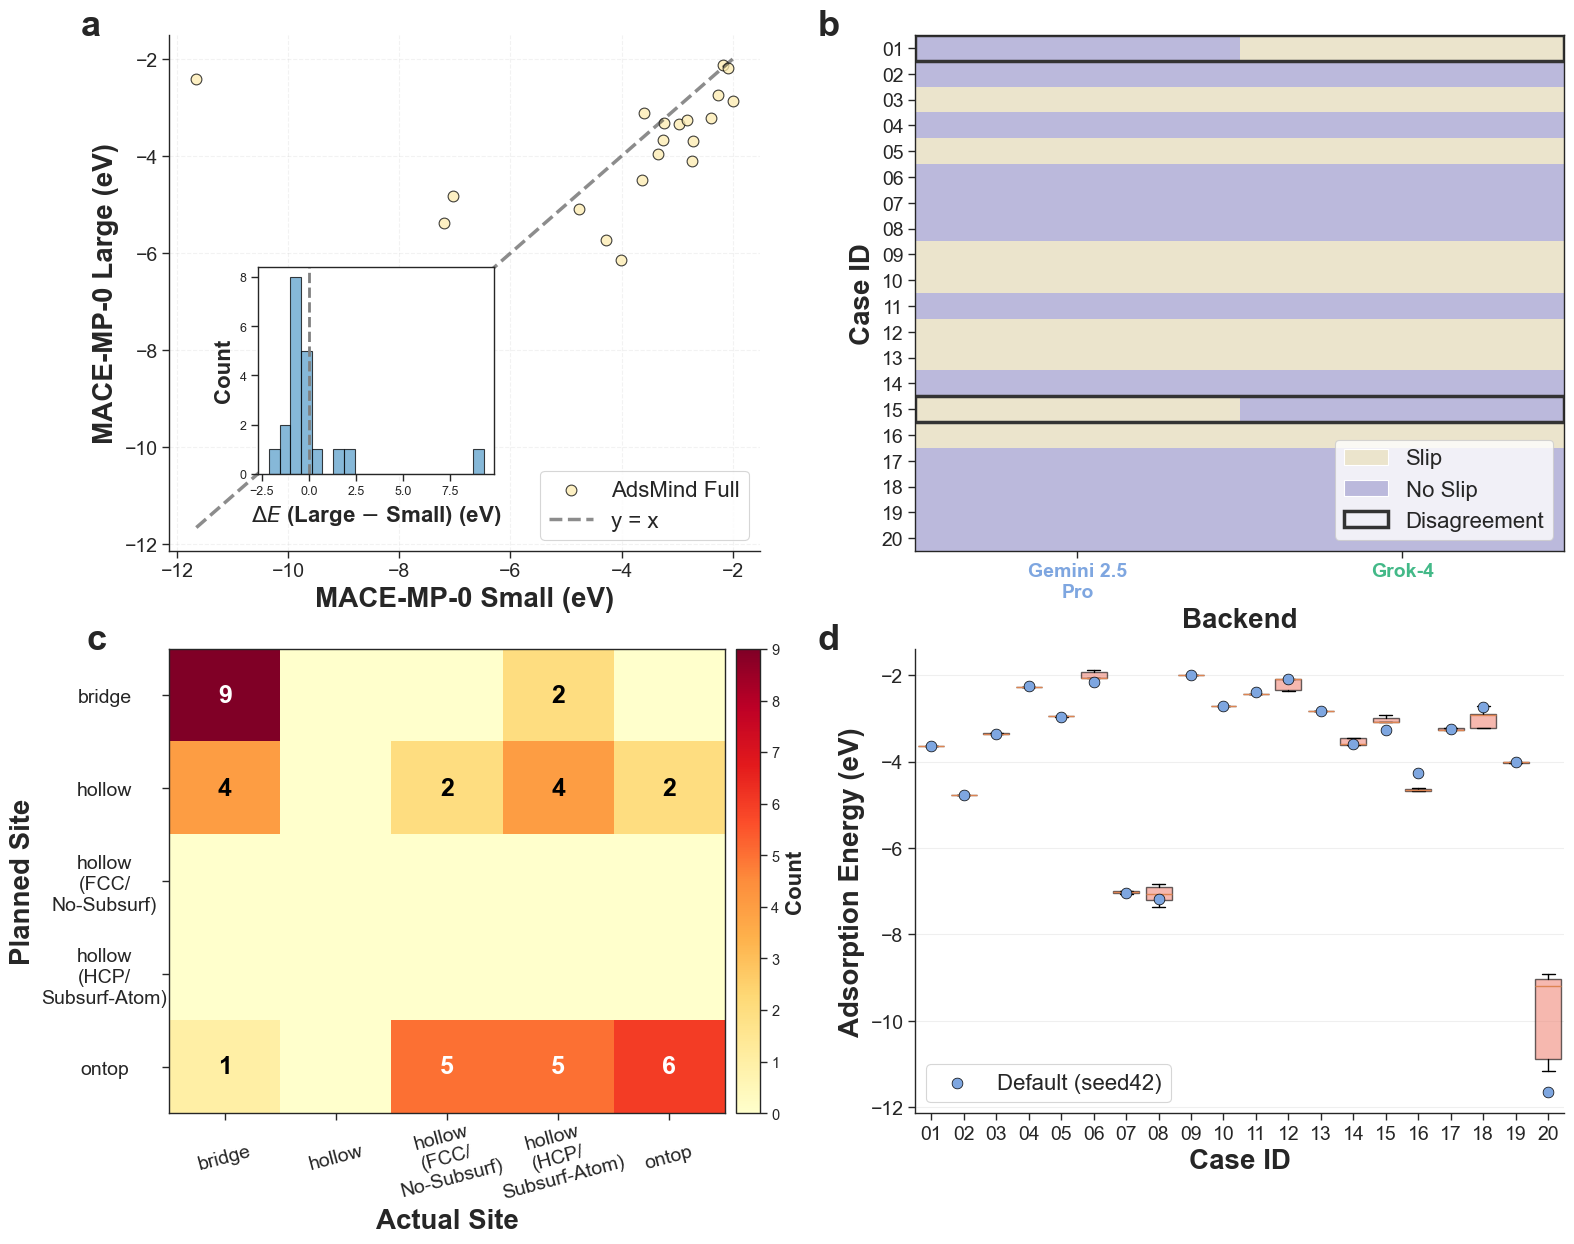

Saved: ./si_figure_S1_combined.png
Done


In [6]:
# ============================================================
# SI FIGURE S2: 2×2 Stability Panels
# ============================================================

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, hspace=0.2, wspace=0.25,
                      height_ratios=[1, 0.9],
                      width_ratios=[1, 1.1])

# ---- Panel (a): MACE Sensitivity (scatter + histogram inset) ----
ax_a = fig.add_subplot(gs[0, 0])

ax_a.scatter(df_cd['small'], df_cd['large'], s=60, alpha=0.75,
            color=okabe[-1], edgecolors='black', label = "AdsMind Full")
lo = min(df_cd[['small', 'large']].min())
hi = max(df_cd[['small', 'large']].max())
ax_a.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, linewidth=2.5, label='y = x')
ax_a.set_xlabel('MACE-MP-0 Small (eV)', fontsize=20, fontweight='bold')
ax_a.set_ylabel('MACE-MP-0 Large (eV)', fontsize=20, fontweight='bold')
ax_a.tick_params(axis='x', labelsize=14)
ax_a.tick_params(axis='y', labelsize=14)
ax_a.legend(fontsize=16, loc='lower right')
ax_a.grid(True, alpha=0.25, linestyle='--')
sns.despine(ax=ax_a)
ax_a.text(-0.15, 1.0, 'a', transform=ax_a.transAxes, fontsize=26, fontweight='bold')

# Inset histogram (adjustable position & size)
INSET_X, INSET_Y = 0.15, 0.15   # position in axes coords
INSET_W, INSET_H = 0.4, 0.4    # width & height
ax_inset = ax_a.inset_axes([INSET_X, INSET_Y, INSET_W, INSET_H])
ax_inset.hist(df_cd['delta'], bins=20, edgecolor='black', alpha=0.75, color=okabe[0])
mean_d = df_cd['delta'].mean()
ax_inset.axvline(0.0, color='grey', linestyle='--', linewidth=2)
ax_inset.set_xlabel(r'$\Delta E$ (Large $-$ Small) (eV)', fontsize=16, fontweight='bold')
ax_inset.set_ylabel('Count', fontsize=16, fontweight='bold')
ax_inset.tick_params(axis='x', labelsize=9)
ax_inset.tick_params(axis='y', labelsize=9)

# ---- Panel (b): Cross-Backend Slip Agreement ----
ax_b = fig.add_subplot(gs[0, 1])

backends_b = ['gemini', 'grok4']
# GPT & Claude: placeholder until data arrives
# backends_b = ['gemini', 'gpt', 'claude', 'grok4']  # target: 4 backends
backend_labels = [panel_a_map[be][1].replace(' 2.5 ', ' 2.5\n') for be in backends_b]
backend_colors = [panel_a_map[be][2] for be in backends_b]
cases_b = sorted(df_slip['case_id'].astype(int).tolist())
slip_matrix = np.zeros((len(cases_b), len(backends_b)))
disagreements = []
for i, cid in enumerate(cases_b):
    row = df_slip[df_slip['case_id'] == cid].iloc[0]
    vals = []
    for j, be in enumerate(backends_b):
        v = 1.0 if str(row[f'{be}_slip']).lower() == 'true' else 0.0
        slip_matrix[i, j] = v
        vals.append(v)
    if vals[0] != vals[1]:
        disagreements.append(cid)


cmap_b = [ "#EBE4CC", '#BBB9DC']
ax_b.imshow(slip_matrix, cmap=plt.matplotlib.colors.ListedColormap(cmap_b), aspect='auto', vmin=0, vmax=1)

for i, cid in enumerate(cases_b):
    if cid in disagreements:
        ax_b.add_patch(plt.Rectangle((-0.5, i - 0.5), len(backends_b), 1,
                                     fill=False, edgecolor='#333', linewidth=2.5, linestyle='-'))

ax_b.set_xticks(np.arange(len(backends_b)))
ax_b.set_xticklabels(backend_labels, fontsize=14)
for tick_label, color in zip(ax_b.get_xticklabels(), backend_colors):
    tick_label.set_color(color)
    tick_label.set_fontweight('bold')
    tick_label.set_fontsize(14)
ax_b.set_yticks(np.arange(len(cases_b)))
ax_b.set_yticklabels([f'{c:02d}' for c in cases_b], fontsize=14)
ax_b.set_xlabel('Backend', fontsize=20, fontweight='bold')
ax_b.set_ylabel('Case ID', fontsize=20, fontweight='bold')

legend_b = [Patch(facecolor=cmap_b[0], label='Slip'),
            Patch(facecolor=cmap_b[1], label='No Slip'),
            Patch(facecolor='none', edgecolor='#333', linewidth=2.5, label='Disagreement')]
ax_b.legend(handles=legend_b, fontsize=16, loc='lower right')
ax_b.text(-0.15, 1.0, 'b', transform=ax_b.transAxes, fontsize=26, fontweight='bold')

# ---- Panel (c): Site Transition Matrix ----
ax_c = fig.add_subplot(gs[1, 0])

trans_counts = df_trans.groupby(['planned', 'actual']).size().unstack(fill_value=0)
all_sites = sorted(set(trans_counts.index) | set(trans_counts.columns))
for s in all_sites:
    if s not in trans_counts.index:
        trans_counts.loc[s] = 0
    if s not in trans_counts.columns:
        trans_counts[s] = 0
trans_counts = trans_counts[all_sites].loc[all_sites]

im_c = ax_c.imshow(trans_counts.values, cmap='YlOrRd', aspect='auto', vmin=0)

def wrap_name(name):
    return name.replace(' (', '\n(').replace('/', '/\n')
wrapped_sites = [wrap_name(s) for s in all_sites]

ax_c.set_xticks(np.arange(len(all_sites)))
ax_c.set_xticklabels(wrapped_sites, fontsize=14, rotation=15, va='center')
ax_c.tick_params(axis='x', pad=27)
ax_c.set_yticks(np.arange(len(all_sites)))
ax_c.set_yticklabels(wrapped_sites, fontsize=14, ha='center')
ax_c.tick_params(axis='y', pad=42)
ax_c.set_xlabel('Actual Site', fontsize=20, fontweight='bold')
ax_c.set_ylabel('Planned Site', fontsize=20, fontweight='bold')

max_val = trans_counts.values.max()
for i in range(len(all_sites)):
    for j in range(len(all_sites)):
        v = trans_counts.iloc[i, j]
        if v > 0:
            ax_c.text(j, i, str(v), ha='center', va='center', fontsize=18,
                     color='white' if v > max_val / 2 else 'black', fontweight='bold')

cbar_c = plt.colorbar(im_c, ax=ax_c, fraction=0.04, pad=0.02)
cbar_c.set_label('Count', fontsize=16, fontweight='bold')
ax_c.text(-0.15, 1.0, 'c', transform=ax_c.transAxes, fontsize=26, fontweight='bold')

# ---- Panel (d): Multi-Seed Reproducibility ----
ax_d = fig.add_subplot(gs[1, 1])

bp = ax_d.boxplot(case_data, positions=np.arange(len(case_data)), widths=0.8,
                  patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(colors[1])
    patch.set_alpha(0.6)

ax_d.scatter(np.arange(len(case_data)), ref_vals, color=colors[0], s=60,
             zorder=5, label='Default (seed42)', edgecolors='black', linewidth=0.5)
ax_d.set_xticks(np.arange(len(case_data)))
ax_d.set_xticklabels(case_labels, fontsize=14)
ax_d.tick_params(axis='x', labelsize=14)
ax_d.tick_params(axis='y', labelsize=14)
ax_d.set_xlabel('Case ID', fontsize=20, fontweight='bold')
ax_d.set_ylabel('Adsorption Energy (eV)', fontsize=20, fontweight='bold')
ax_d.legend(fontsize=16, loc='lower left')
ax_d.grid(True, alpha=0.3, axis='y')
sns.despine(ax=ax_d)
ax_d.text(-0.15, 1.0, 'd', transform=ax_d.transAxes, fontsize=26, fontweight='bold')

# ---- Save ----
plt.savefig('./si_figure_S1_combined.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: ./si_figure_S1_combined.png')
print('Done')
